In [10]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics.pairwise import cosine_similarity
import pytensor.tensor as pt
import pymc as pm
from __future__ import annotations
from pathlib import Path
import os

import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

In [11]:
# ------------------------------------------------------------
# 0) Define Data Path
# ------------------------------------------------------------
try:
    # 1. Preferred method for scripts (.py files):
    # Get the directory of the current script file.
    BASE_DIR = Path(__file__).parent
except NameError:
    # 2. Fallback for notebooks (Colab/Jupyter):
    # Use the current working directory, which should be the Git root
    # after cloning and changing directory (see Colab setup below).
    BASE_DIR = Path(os.getcwd())

# Define the relative path to the raw data folder
RAW_DATA_PATH = BASE_DIR / "data"

# Sanity check (Optional, but useful for debugging)
if not RAW_DATA_PATH.is_dir():
    raise FileNotFoundError(
        f"The data/raw directory was not found at the expected path: {RAW_DATA_PATH}"
    )

print(f"Data will be loaded from: {RAW_DATA_PATH}")


# ------------------------------------------------------------
# 1) Load data
# ------------------------------------------------------------
# ------------------------------------------------------------
# Use the RAW_DATA_PATH variable and the / operator from pathlib
# to construct the full file path.

df_sorted = pd.read_excel(RAW_DATA_PATH / "df_sorted.xlsx")
df_lan = pd.read_excel(RAW_DATA_PATH / "language.harvard.xlsx")
df_rel = pd.read_excel(RAW_DATA_PATH /'religous.xlsx')

Data will be loaded from: /content/Silk-Road-Tourism-Spillovers-Spatial-Bayesian-Durbin-Model/Silk-Road-Tourism-Spillovers-Spatial-Bayesian-Durbin-Model/data


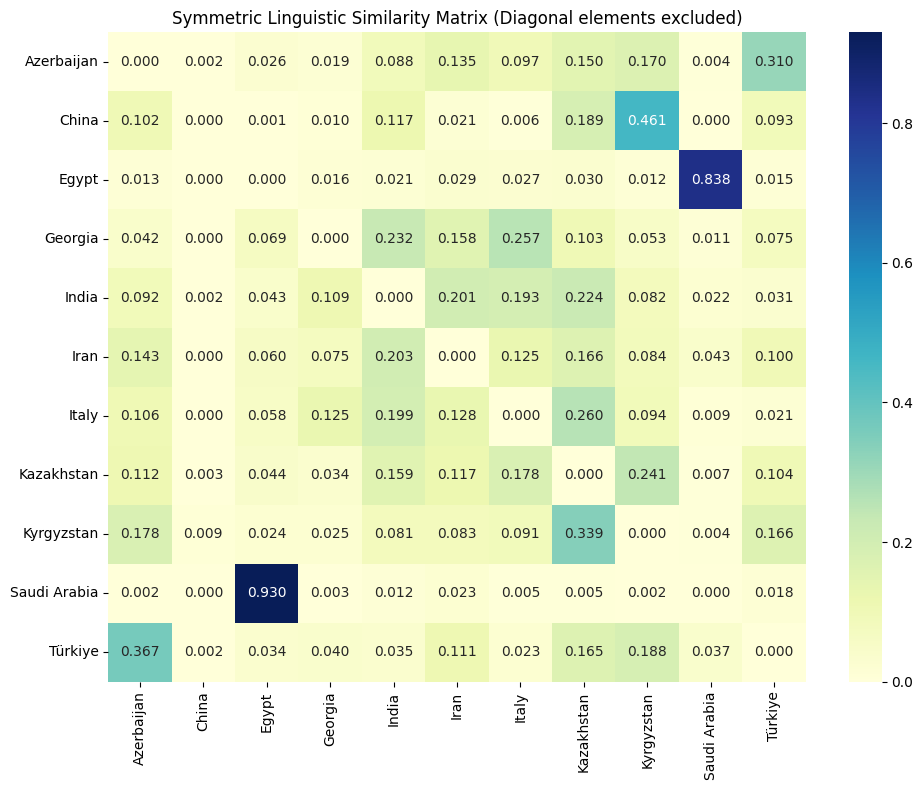

In [12]:
# Extract a unique list of all countries appearing in either column
countries = sorted(set(df_lan['country_i'].unique()).union(df_lan['country_j'].unique()))

# Create float matrix
W = pd.DataFrame(0.0, index=countries, columns=countries)

# Fill matrix
for _, row in df_lan.iterrows():
    i = row['country_i']
    j = row['country_j']
    if i != j:
        W.loc[i, j] = row['lps']

# Force diagonal to zero
np.fill_diagonal(W.values, 0)

# Normalize
W_normalized_lan = W.div(W.sum(axis=1), axis=0)


# Visualize and validate the matrix ---

plt.figure(figsize=(10, 8))
sns.heatmap(
    W_normalized_lan,
    xticklabels=countries,
    yticklabels=countries,
    cmap="YlGnBu",
    annot=True,
    fmt=".3f"  # Display 3 decimal places for precision
)
plt.title("Symmetric Linguistic Similarity Matrix (Diagonal elements excluded)")
plt.tight_layout()
plt.show()



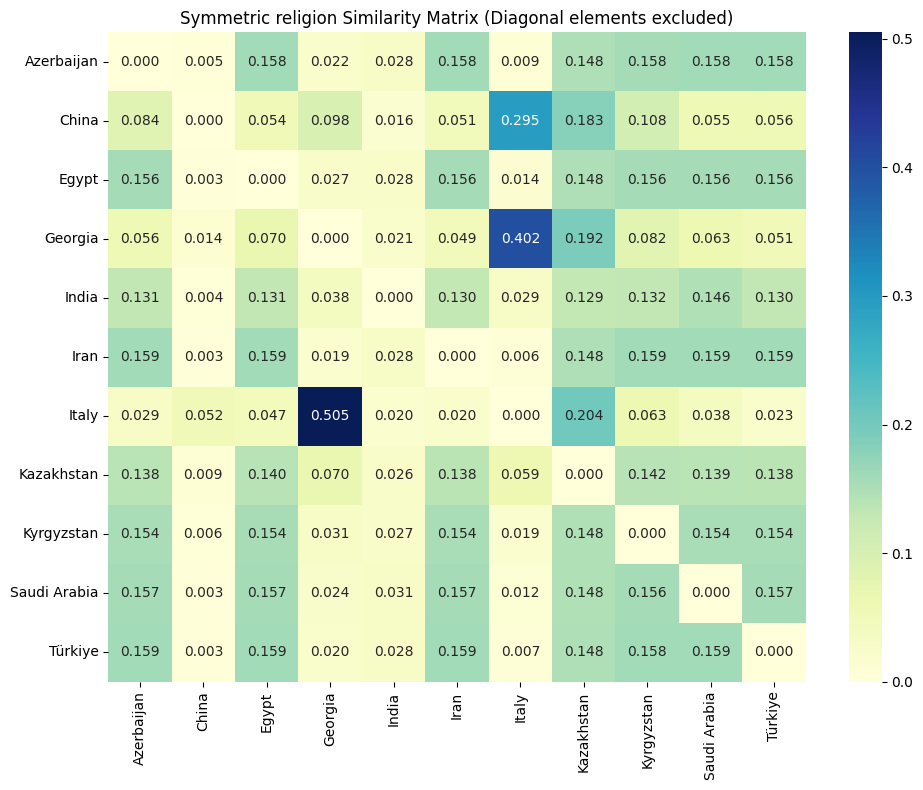

In [13]:
# Columns representing the population counts of each religion

religion_cols = ['Christians', 'Muslims', 'Unaffiliated', 'Hindus', 'Buddhists', 'Other religions', 'Jews']

# Row normalization: each value is divided by the row sum

df_rel[religion_cols] = df_rel[religion_cols].div(df_rel[religion_cols].sum(axis=1), axis=0)

# Extract religious composition vectors

vectors = df_rel[religion_cols].values

# Compute cosine similarity between all countries

similarity_matrix = cosine_similarity(vectors)

# Convert to DataFrame with country names as index/columns

countries = df_rel['Country'].values  # فرض کنید نام کشورها در ستون 'Country' است
W_religion = pd.DataFrame(similarity_matrix, index=countries, columns=countries)

# Zero out diagonal (no self-connection)

np.fill_diagonal(W_religion.values, 0)

# Row-normalize so that each row sums to 1 (handle division by zero)

W_normalized_religion = W_religion.div(W_religion.sum(axis=1).replace(0, 1), axis=0)



# Visualize and validate the matrix ---

plt.figure(figsize=(10, 8))
sns.heatmap(
    W_normalized_religion,
    xticklabels=countries,
    yticklabels=countries,
    cmap="YlGnBu",
    annot=True,
    fmt=".3f"  # Display 3 decimal places for precision
)
plt.title("Symmetric religion Similarity Matrix (Diagonal elements excluded)")
plt.tight_layout()
plt.show()


In [14]:
# Set the weight (alpha) for the language-based matrix
alpha = 0.4  # weight of the language component

# Combine the language and religion matrices using a weighted average
W_combined_04 = alpha * W_normalized_lan + (1 - alpha) * W_normalized_religion

# Set diagonal values to zero (to remove self-connections)
np.fill_diagonal(W_combined_04.values, 0)

# Row-normalize the combined matrix so that each row sums to 1
W_combined_normalized_04 = W_combined_04.div(W_combined_04.sum(axis=1), axis=0)


# (Alternative clean version)
# Create a copy of the combined matrix and zero out the diagonal
W_cleaned_04 = W_combined_04.copy()
np.fill_diagonal(W_cleaned_04.values, 0)

# Perform row normalization again to ensure consistency
W_combined_normalized_04 = W_cleaned_04.div(W_cleaned_04.sum(axis=1), axis=0)

W_cul04 = W_combined_normalized_04

In [15]:
W_cul04 = pd.DataFrame(W_cul04, columns=countries, index=countries)

W_cul04.to_excel("W_cul04.xlsx")

In [16]:
# Set the weight (alpha) for the language-based matrix
alpha = 0.5  # weight of the language component

# Combine the language and religion matrices using a weighted average
W_combined_05 = alpha * W_normalized_lan + (1 - alpha) * W_normalized_religion

# Set diagonal values to zero (to remove self-connections)
np.fill_diagonal(W_combined_05.values, 0)

# Row-normalize the combined matrix so that each row sums to 1
W_combined_normalized_05 = W_combined_05.div(W_combined_05.sum(axis=1), axis=0)


# (Alternative clean version)
# Create a copy of the combined matrix and zero out the diagonal
W_cleaned_05 = W_combined_05.copy()
np.fill_diagonal(W_cleaned_05.values, 0)

# Perform row normalization again to ensure consistency
W_combined_normalized_05 = W_cleaned_05.div(W_cleaned_05.sum(axis=1), axis=0)

W_cul05 = W_combined_normalized_05

In [17]:
W_cul05 = pd.DataFrame(W_cul05, columns=countries, index=countries)
W_cul05.to_excel("W_cul05.xlsx")

In [18]:
# Set the weight (alpha) for the language-based matrix
alpha = 0.6  # weight of the language component

# Combine the language and religion matrices using a weighted average
W_combined_06 = alpha * W_normalized_lan + (1 - alpha) * W_normalized_religion

# Set diagonal values to zero (to remove self-connections)
np.fill_diagonal(W_combined_06.values, 0)

# Row-normalize the combined matrix so that each row sums to 1
W_combined_normalized_06 = W_combined_06.div(W_combined_06.sum(axis=1), axis=0)


# (Alternative clean version)
# Create a copy of the combined matrix and zero out the diagonal
W_cleaned_06 = W_combined_06.copy()
np.fill_diagonal(W_cleaned_06.values, 0)

# Perform row normalization again to ensure consistency
W_combined_normalized_06 = W_cleaned_06.div(W_cleaned_06.sum(axis=1), axis=0)

W_cul06 = W_combined_normalized_06

In [19]:
W_cul06 = pd.DataFrame(W_cul06, columns=countries, index=countries)
W_cul06.to_excel("W_cul06.xlsx")